# Lab 4 (Python Programming IV)
## Foundations of Artificial Intelligence and Data Science (AI101)

### Practicing numerical computation in Python through vectors, matrices, basic statistics, simple mathematical operations, and small exercises connected to foundational AI and data science concepts.

---
Welcome to **Lab 4 / DPP 4**!

So far in your previous labs, you have learned about variables, data types, conditionals, loops, strings, lists, tuples, dictionaries, and functions.

Now, we take the next step — **working with numbers at scale**. In Artificial Intelligence and Data Science, almost everything boils down to numbers:
- An image is just a grid of numbers (pixel values).
- A recommendation system compares users by looking at lists of numbers (ratings).
- A spam classifier uses counts of words (again, numbers!) to decide if an email is spam.

To handle all of this, we need to learn how to **work with vectors (1D lists of numbers)**, **matrices (2D grids of numbers)**, and **basic statistics** (summarizing data).

Don't worry if some of these terms sound new — we will explain everything from scratch with simple examples!

**What you will learn today:**
1. Vectors — Think of them as "smart lists of numbers" with math superpowers.
2. Matrices — Think of them as "tables / grids of numbers".
3. Basic Statistics — How to summarize and understand data (mean, median, etc.).
4. Useful Math for AI — Distance between points, scaling data, simple AI building blocks.

**Note:** We will use a Python library called **NumPy** (Numerical Python). It makes working with numbers much faster and easier than plain Python lists.

### ▶ **Vectors — Lists of Numbers with Math Powers**

**What is a vector?**

Simply put, a **vector** is an ordered list of numbers. That's it!

For example:
- Your marks in 4 subjects → `[85, 72, 90, 68]` — this is a vector of size 4.
- Temperature readings over 3 days → `[32.5, 30.1, 35.0]` — this is a vector of size 3.

In AI & Data Science, each data point (like a student, a product, or an image) is often represented as a vector.

**Why not just use Python lists?**

Python lists work, but they don't do math automatically. For example, if you try `[1, 2, 3] + [4, 5, 6]` in Python, it gives you `[1, 2, 3, 4, 5, 6]` (concatenation), NOT `[5, 7, 9]` (addition).

That's where **NumPy** comes in! It gives us arrays that behave like mathematical vectors.

In [ ]:
!pip install numpy

In [ ]:
# First, let's import NumPy — we only need to do this once at the top
import numpy as np

# Creating a vector using a Python list:
marks_list = [85, 72, 90, 68]
print("Python list:", marks_list)
print("Type:", type(marks_list))

# Creating a vector using NumPy:
marks = np.array([85, 72, 90, 68])
print("\nNumPy array:", marks)
print("Type:", type(marks))
print("Shape:", marks.shape)       # (4,) means 1D array with 4 elements
print("Size:", len(marks))          # 4 elements

Python list: [85, 72, 90, 68]
Type: <class 'list'>

NumPy array: [85 72 90 68]
Type: <class 'numpy.ndarray'>
Shape: (4,)
Size: 4


**Vector Arithmetic: Adding, Subtracting, and Scaling**

With NumPy arrays, math works just the way you would expect:

- **Addition:** `[1, 2, 3] + [4, 5, 6] = [5, 7, 9]` → adds element by element
- **Subtraction:** `[5, 7, 9] - [4, 5, 6] = [1, 2, 3]`
- **Scalar Multiplication:** `3 × [1, 2, 3] = [3, 6, 9]` → multiplies each element by the number
- **Element-wise Multiplication:** `[1, 2, 3] × [4, 5, 6] = [4, 10, 18]`

![Vector Addition — Element by Element](/content/images/01_vector_addition.jpg)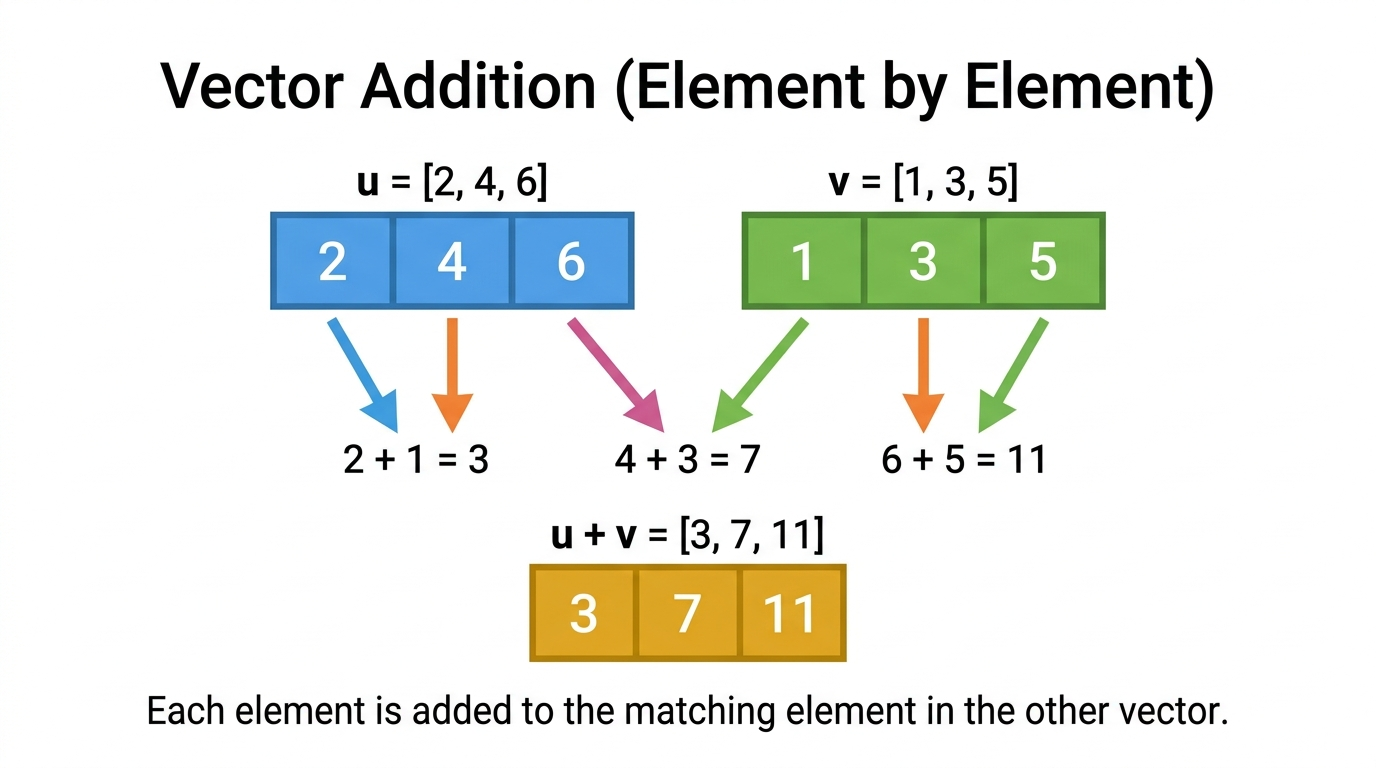

In [ ]:
# Let's see the difference between lists and NumPy arrays:
list_a = [1, 2, 3]
list_b = [4, 5, 6]
print("Python list + :", list_a + list_b)  # Concatenation! Not math!

# Now with NumPy:
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

print("\nNumPy Addition (a + b):", a + b)          # [5, 7, 9]
print("NumPy Subtraction (a - b):", a - b)        # [-3, -3, -3]
print("Scalar Multiplication (3 * a):", 3 * a)    # [3, 6, 9]
print("Element-wise Multiply (a * b):", a * b)    # [4, 10, 18]

Python list + : [1, 2, 3, 4, 5, 6]

NumPy Addition (a + b): [5 7 9]
NumPy Subtraction (a - b): [-3 -3 -3]
Scalar Multiplication (3 * a): [3 6 9]
Element-wise Multiply (a * b): [ 4 10 18]


**Dot Product — A Very Important Operation**

The **dot product** of two vectors takes matching elements, multiplies them, and adds up all the results.

$u \cdot v = u_1 \times v_1 + u_2 \times v_2 + u_3 \times v_3 + \dots$

**Example:**
- $u = [1, 2, 3]$, $v = [4, 5, 6]$
- Dot product $= 1 \times 4 + 2 \times 5 + 3 \times 6 = 4 + 10 + 18 = 32$

**Why is this useful?** The dot product tells us how "similar" or "aligned" two vectors are — this is used everywhere in AI (search engines, recommendation systems, image recognition).

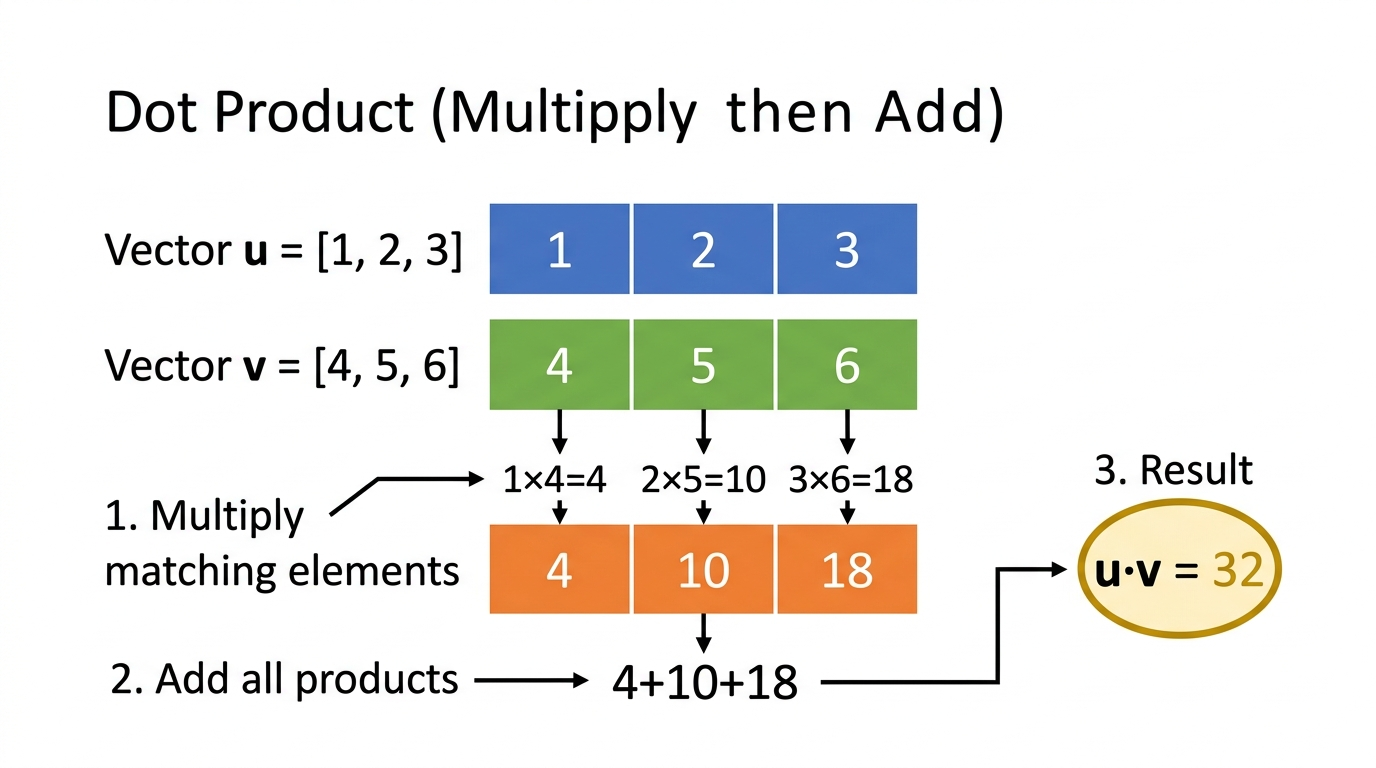![Dot Product — Multiply then Add](/content/images/02_dot_product.jpg)

In [ ]:
# Dot Product — From scratch using a for loop:
u = [1, 2, 3]
v = [4, 5, 6]

dot_product = 0
for i in range(len(u)):
    dot_product = dot_product + u[i] * v[i]
print("Dot product (from scratch):", dot_product)

# Dot Product — Using NumPy (much easier!):
u_np = np.array(u)
v_np = np.array(v)
print("Dot product (NumPy):", np.dot(u_np, v_np))

Dot product (from scratch): 32
Dot product (NumPy): 32


**Magnitude (Length) of a Vector & Normalization**

The **magnitude** (or **length** or **norm**) of a vector tells you "how long" the vector is. Think of it like the hypotenuse formula from school:

For a vector $u = [u_1, u_2, u_3]$:

$$\|u\| = \sqrt{u_1^2 + u_2^2 + u_3^2}$$

For example, $u = [3, 4]$ → magnitude $= \sqrt{3^2 + 4^2} = \sqrt{9 + 16} = \sqrt{25} = 5$

**Normalization** means converting a vector so its magnitude becomes exactly 1.0 (a "unit vector"). You do this by dividing each element by the magnitude:

$$\hat{u} = \frac{u}{\|u\|}$$

This is useful when you care about the **direction** of data, not the **size** (e.g., comparing document topics regardless of document length).

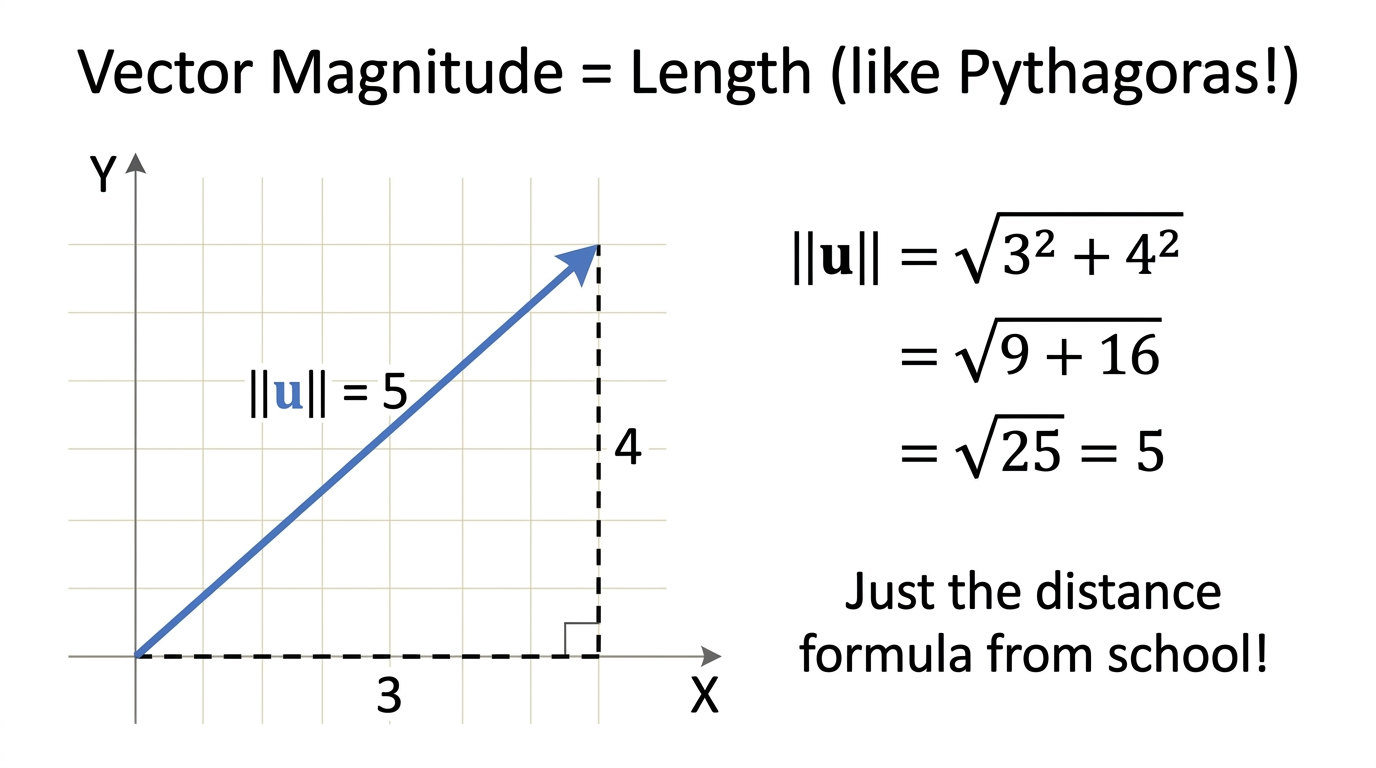![Vector Magnitude — Like Pythagoras!](images/03_vector_magnitude.jpg)

In [ ]:
# Magnitude — From scratch:
u = np.array([3.0, 4.0])
magnitude_scratch = (u[0]**2 + u[1]**2) ** 0.5
print("Magnitude (scratch):", magnitude_scratch)  # 5.0

# Magnitude — Using NumPy:
magnitude_np = np.linalg.norm(u)
print("Magnitude (NumPy):", magnitude_np)  # 5.0

# Normalization — Making a unit vector:
u_unit = u / magnitude_np
print("\nOriginal vector u:", u)
print("Unit vector (normalized):", u_unit)
print("Magnitude of unit vector:", np.linalg.norm(u_unit))  # Should be 1.0

Magnitude (scratch): 5.0
Magnitude (NumPy): 5.0

Original vector u: [3. 4.]
Unit vector (normalized): [0.6 0.8]
Magnitude of unit vector: 1.0


**Cosine Similarity — How similar are two vectors?**

Sometimes we want to check how "similar" two vectors are in direction (ignoring their sizes).

**Cosine Similarity** gives a score between:
- **+1** → vectors point in the exact same direction (very similar)
- **0** → vectors are perpendicular (no similarity)
- **-1** → vectors point in opposite directions

$$\text{Cosine Similarity} = \frac{u \cdot v}{\|u\| \times \|v\|}$$

**Real-world use:** Search engines compare your search query vector with document vectors using cosine similarity to find the most relevant results!

In [ ]:
# Cosine Similarity Example:
student_A = np.array([85, 90, 78])  # Marks in 3 subjects
student_B = np.array([80, 88, 75])  # Similar student
student_C = np.array([40, 30, 95])  # Very different pattern

def cosine_similarity(v1, v2):
    dot = np.dot(v1, v2)
    mag1 = np.linalg.norm(v1)
    mag2 = np.linalg.norm(v2)
    return dot / (mag1 * mag2)

sim_AB = cosine_similarity(student_A, student_B)
sim_AC = cosine_similarity(student_A, student_C)

print(f"Similarity between A and B: {sim_AB:.4f}")  # High (close to 1)
print(f"Similarity between A and C: {sim_AC:.4f}")  # Lower

Similarity between A and B: 0.9999
Similarity between A and C: 0.8601


#### 📝 **Try It Yourself — Easy Vector Questions**

**E1: Create a NumPy array with your marks in 5 subjects. Print the array and its shape.**

In [ ]:
# E1: Code here


**E2: Create two NumPy arrays: `a = [10, 20, 30]` and `b = [1, 2, 3]`. Print their sum, difference, and element-wise product.**

In [ ]:
# E2: Code here


**E3: Calculate the dot product of `[2, 3, 4]` and `[5, 6, 7]` using both a `for` loop and `np.dot()`. Verify they give the same answer.**

In [ ]:
# E3: Code here


**E4: Find the magnitude (length) of the vector `[6, 8]` using the formula $\sqrt{6^2 + 8^2}$ and verify with `np.linalg.norm()`.**

In [ ]:
# E4: Code here


### ▶ **Matrices — Tables of Numbers**

**What is a matrix?**

A **matrix** is simply a **2D grid (table) of numbers** arranged in rows and columns.

Think of it like an Excel spreadsheet! For example, marks of 3 students in 4 subjects:

|        | Maths | Physics | Chemistry | English |
|--------|-------|---------|-----------|---------|
| Student 1 | 85 | 72 | 90 | 68 |
| Student 2 | 78 | 85 | 65 | 92 |
| Student 3 | 90 | 88 | 78 | 75 |

This is a **3 × 4 matrix** (3 rows, 4 columns).

In AI & Data Science:
- A dataset of 1000 students with 5 features each → matrix of shape (1000, 5)
- A grayscale image of 28×28 pixels → matrix of shape (28, 28)
- Weight connections between neural network layers → matrices

In [ ]:
# Creating a matrix using NumPy:
# Marks of 3 students in 4 subjects
marks_matrix = np.array([
    [85, 72, 90, 68],   # Student 1
    [78, 85, 65, 92],   # Student 2
    [90, 88, 78, 75]    # Student 3
])

print("Marks Matrix:")
print(marks_matrix)
print("\nShape (rows, columns):", marks_matrix.shape)  # (3, 4)
print("Total elements:", marks_matrix.size)             # 12
print("Number of rows:", marks_matrix.shape[0])         # 3
print("Number of columns:", marks_matrix.shape[1])      # 4

Marks Matrix:
[[85 72 90 68]
 [78 85 65 92]
 [90 88 78 75]]

Shape (rows, columns): (3, 4)
Total elements: 12
Number of rows: 3
Number of columns: 4


**Accessing Elements: Indexing and Slicing**

Just like lists, we can access specific elements, rows, or columns:
- `M[row, col]` → one element (remember: indexing starts from 0!)
- `M[row, :]` → an entire row
- `M[:, col]` → an entire column
- `M[r1:r2, c1:c2]` → a sub-block of the matrix

In [ ]:
# marks_matrix via list[lists]
marks = [[10, 20, 30], [23, 45, 67], [48, 20, 56]]

print(marks[1][:])

[23, 45, 67]


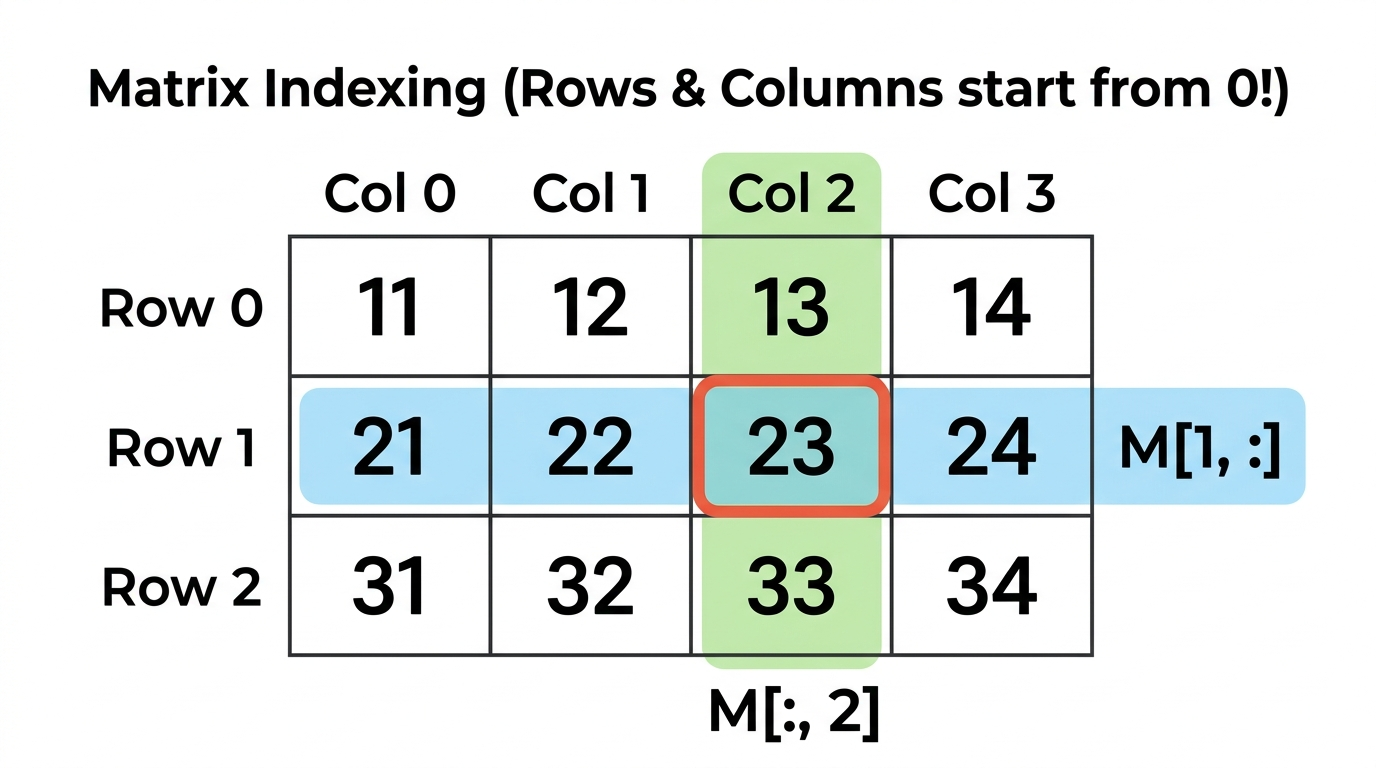![Matrix Indexing — Rows and Columns](images/04_matrix_indexing.jpg)

In [ ]:
marks_matrix = np.array([
    [85, 72, 90, 68],   # Student 1
    [78, 85, 65, 92],   # Student 2
    [90, 88, 78, 75]    # Student 3
])

# Accessing elements:
print("Student 1, Subject 3 (row 0, col 2):", marks_matrix[0, 2])  # 90

# Accessing a full row:
print("All marks of Student 2 (row 1):", marks_matrix[1, :])  # [78, 85, 65, 92]

# Accessing a full column:
print("All Maths marks (col 0):", marks_matrix[:, 0])  # [85, 78, 90]

# Accessing a sub-block: First 2 students, first 2 subjects
print("Sub-block (2x2):\n", marks_matrix[0:2, 0:2])

Student 1, Subject 3 (row 0, col 2): 90
All marks of Student 2 (row 1): [78 85 65 92]
All Maths marks (col 0): [85 78 90]
Sub-block (2x2):
 [[85 72]
 [78 85]]


**Special Matrices & Transpose**

NumPy can create some commonly used special matrices:
- `np.zeros((rows, cols))` → all elements are 0
- `np.ones((rows, cols))` → all elements are 1
- `np.eye(n)` → **Identity Matrix** (1s on diagonal, 0s everywhere else)

**Transpose ($A^T$)**: Swaps rows and columns. Row 1 becomes Column 1, Row 2 becomes Column 2, and so on.

$$\text{If } A = \begin{bmatrix} 1 & 2 \\ 3 & 4 \\ 5 & 6 \end{bmatrix} \text{ then } A^T = \begin{bmatrix} 1 & 3 & 5 \\ 2 & 4 & 6 \end{bmatrix}$$

In [ ]:
# Special Matrices:
print("Zeros (2x3):\n", np.zeros((2, 3)))
print("\nOnes (3x2):\n", np.ones((3, 2)))
print("\nIdentity (3x3):\n", np.eye(3))

# Transpose:
A = np.array([
    [1, 2],
    [3, 4],
    [5, 6]
])
print("\nOriginal A (3x2):")
print(A)
print("\nTranspose A^T (2x3):")
print(A.T)

Zeros (2x3):
 [[0. 0. 0.]
 [0. 0. 0.]]

Ones (3x2):
 [[1. 1.]
 [1. 1.]
 [1. 1.]]

Identity (3x3):
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

Original A (3x2):
[[1 2]
 [3 4]
 [5 6]]

Transpose A^T (2x3):
[[1 3 5]
 [2 4 6]]


**Matrix Multiplication**

Matrix multiplication is NOT just multiplying matching elements. Instead, it involves **dot products** between rows and columns.

If matrix $A$ has shape $(m, k)$ and matrix $B$ has shape $(k, n)$, then $C = A \times B$ has shape $(m, n)$.

**Important rule:** The number of **columns in A** must equal the number of **rows in B**.

$$C_{ij} = \text{(Row } i \text{ of A)} \cdot \text{(Column } j \text{ of B)}$$

**Real example:** In a neural network, input data $x$ is transformed using $y = Wx + b$ where $W$ is a weight matrix, $x$ is the input vector, and $b$ is a bias. **Don't Worry if you don't understand neural network now, you will lern about them more in future**

**In NumPy:**
- `A * B` → Element-wise multiplication (each element multiplied separately) — NOT matrix multiplication!
- `A @ B` or `np.dot(A, B)` → Proper matrix multiplication

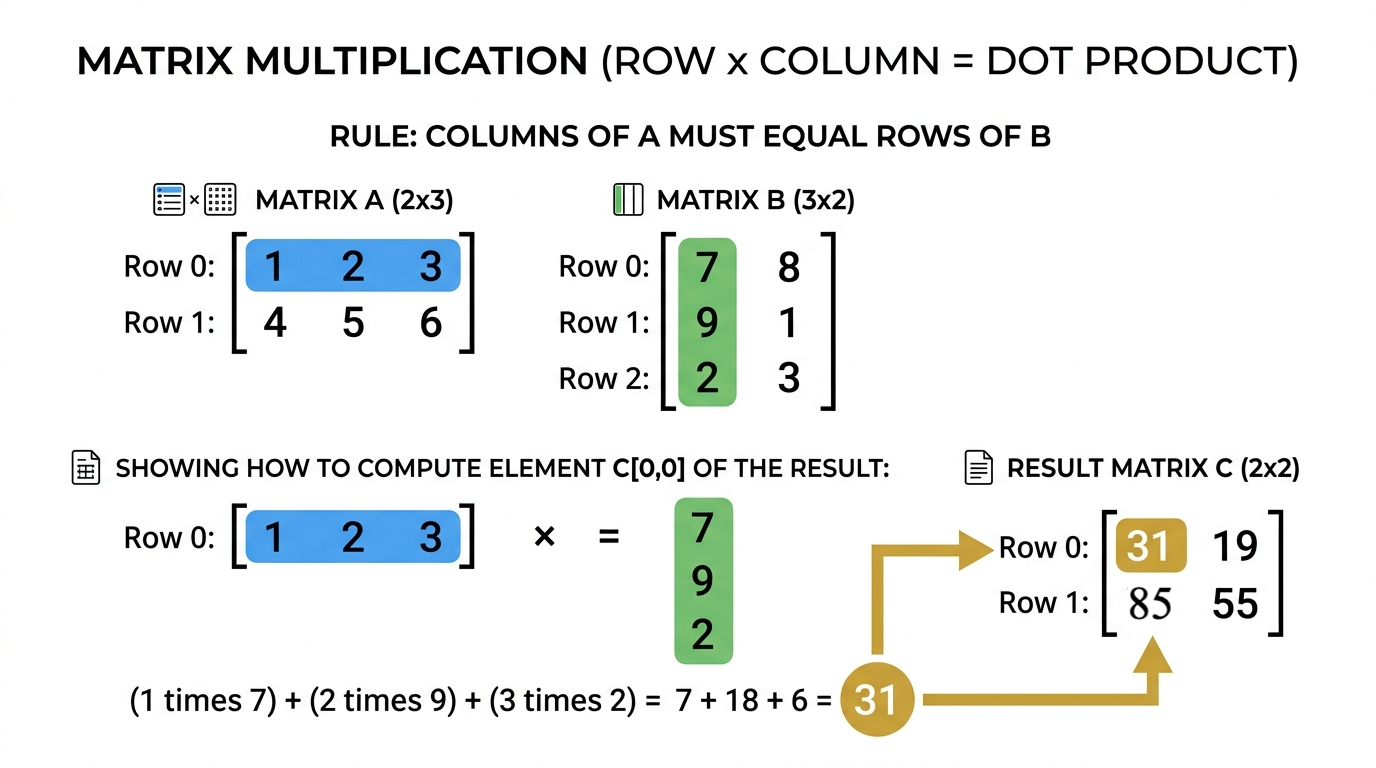![Matrix Multiplication — Row × Column = Dot Product](images/05_matrix_multiplication.jpg)

In [ ]:
# Matrix-Vector Multiplication Example:
# Imagine a tiny neural network layer with 2 outputs and 3 inputs
W = np.array([
    [0.5, -0.2, 0.1],    # weights for output 1
    [0.3,  0.8, -0.5]    # weights for output 2
])  # Shape: (2, 3)

x = np.array([2.0, 4.0, 1.0])  # 3 input features
b = np.array([0.1, -0.2])      # 2 biases

# Linear transformation: y = W @ x + b
Wx = W @ x     # Matrix-vector product: (2,3) @ (3,) = (2,)
y = Wx + b

print("Weight matrix W (2x3):\n", W)
print("Input vector x:", x)
print("W @ x =", Wx)
print("y = W @ x + b =", y)

# Matrix-Matrix Multiplication:
A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])

print("\nA @ B (matrix multiplication):\n", A @ B)
print("\nA * B (element-wise, NOT matrix mult):\n", A * B)

Weight matrix W (2x3):
 [[ 0.5 -0.2  0.1]
 [ 0.3  0.8 -0.5]]
Input vector x: [2. 4. 1.]
W @ x = [0.3 3.3]
y = W @ x + b = [0.4 3.1]

A @ B (matrix multiplication):
 [[19 22]
 [43 50]]

A * B (element-wise, NOT matrix mult):
 [[ 5 12]
 [21 32]]


#### 📝 **Try It Yourself — Easy Matrix Questions**

**E5: Create a 3×3 NumPy matrix with numbers 1 to 9. Print the matrix, its shape, and the element in row 1, column 2 (remember: indexing starts at 0!).**

In [ ]:
# E5: Code here
# Hint: You can use np.array([[1,2,3], [4,5,6], [7,8,9]])
# Or even np.arange(1, 10).reshape(3, 3)


**E6: Using the matrix from E5, extract and print:**
1. **The second row (index 1)**
2. **The third column (index 2)**
3. **The top-left 2×2 submatrix**

In [ ]:
# E6: Code here


**E7: Create a 3×3 Identity matrix using `np.eye(3)`. Multiply it with any 3×3 matrix using `@`. What do you observe about the result?**

In [ ]:
# E7: Code here


**E8: Create a matrix $A$ of shape (2, 3) and compute its transpose $A^T$. Print both and verify that the shapes are swapped.**

In [ ]:
# E8: Code here


### ▶ **Basic Statistics — Making Sense of Data**

Before building any AI model, the first thing a data scientist does is **understand the data** by computing simple statistics. Let's learn the most important ones:

**1. Mean (Average) $\bar{x}$:** Add all values and divide by count.
$$\bar{x} = \frac{x_1 + x_2 + \dots + x_N}{N}$$
*Example: Mean of [10, 20, 30] = (10+20+30)/3 = 20*

**2. Median:** The **middle value** when data is sorted. If there are even number of values, take the average of the two middle ones.
*Example: Median of [3, 1, 7, 5, 9] → sorted: [1, 3, 5, 7, 9] → median = 5*
*Example: Median of [3, 1, 7, 5] → sorted: [1, 3, 5, 7] → median = (3+5)/2 = 4*

**Why is median useful?** It is **not affected by extreme values (outliers)**.
Imagine salaries: [20K, 25K, 22K, 30K, 500K]. Mean = 119.4K (misleading!), Median = 25K (more realistic).

**3. Mode:** The value that appears **most frequently**.
*Example: Mode of [5, 3, 5, 7, 5, 8] = 5 (appears 3 times)*

**4. Variance ($\sigma^2$) and Standard Deviation ($\sigma$):** Tell you how **spread out** the data is.
- **Variance:** Average of squared differences from the mean.
$$\sigma^2 = \frac{1}{N} \sum_{i=1}^N (x_i - \bar{x})^2$$
- **Standard Deviation:** Square root of variance (in same units as data).
$$\sigma = \sqrt{\sigma^2}$$

*Small $\sigma$ = data is clustered together. Large $\sigma$ = data is spread out.*

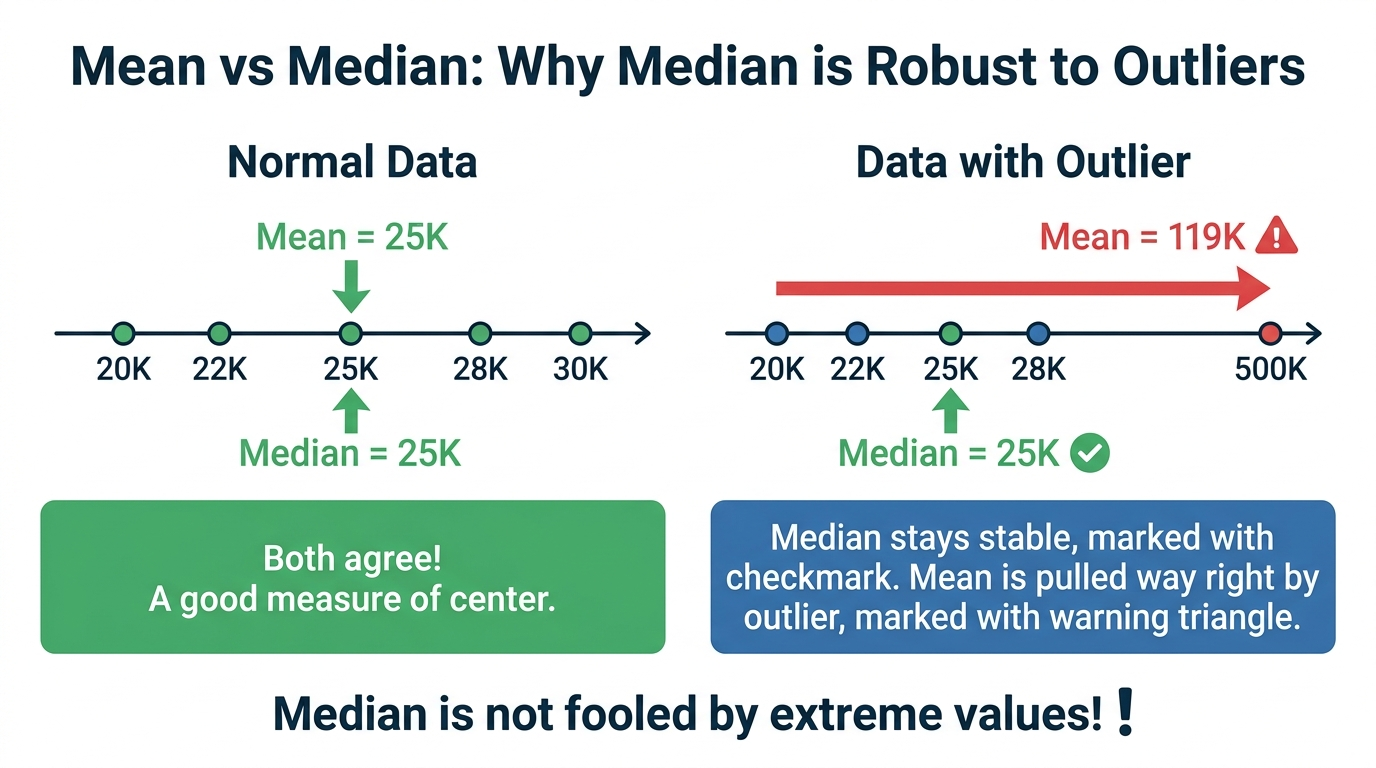![Mean vs Median — Median is Robust to Outliers](images/06_mean_vs_median.jpg)

In [ ]:
# Let's compute stats on exam scores:
scores = np.array([72, 85, 90, 60, 72, 88, 95, 72, 50, 68])

# Mean:
mean = np.mean(scores)
print(f"Mean: {mean}")

# Median:
median = np.median(scores)
print(f"Median: {median}")

# Mode (using Python's Counter):
from collections import Counter
counts = Counter(scores)
mode = counts.most_common(1)[0]
print(f"Mode: {mode[0]} (appears {mode[1]} times)")

# Variance and Standard Deviation:
variance = np.var(scores)
std_dev = np.std(scores)
print(f"\nVariance: {variance:.2f}")
print(f"Standard Deviation: {std_dev:.2f}")

# Range, Min, Max:
print(f"\nMin: {np.min(scores)}, Max: {np.max(scores)}, Range: {np.max(scores) - np.min(scores)}")

Mean: 75.2
Median: 72.0
Mode: 72 (appears 3 times)

Variance: 181.96
Standard Deviation: 13.49

Min: 50, Max: 95, Range: 45


**4. Variance ($\sigma^2$ or $s^2$) and Standard Deviation:** Tell you how **spread out** the data is.
- **Population Variance ($\sigma^2$):** Used when you have the entire population data. Average of squared differences from the mean.
$$\sigma^2 = \frac{1}{N} \sum_{i=1}^N (x_i - \mu)^2$$
- **Sample Variance ($s^2$):** Used when you have a sample representing a population. Divides by $N-1$ instead of $N$ (Bessel's correction) to give an unbiased estimate.
$$s^2 = \frac{1}{N-1} \sum_{i=1}^n (x_i - \bar{x})^2$$
- **Standard Deviation:** Square root of variance (in same units as data).
$$\sigma = \sqrt{\sigma^2} \quad \text{or} \quad s = \sqrt{s^2}$$

*Small standard deviation = data is clustered together. Large standard deviation = data is spread out.*


**Understanding `ddof` (Delta Degrees of Freedom):**
`ddof` determines whether we divide by $N$ (using `ddof=0` for Population Variance) or $N-1$ (using `ddof=1` for Sample Variance) when calculating variance. Its significance is that setting `ddof=1` provides an *unbiased estimate* of the true population variance when you only have a smaller sample of data to work with.


In [ ]:
# E11: Code here
import numpy as np
data = [10, 20, 30, 40, 50]

# NumPy solution:
# Population variance (divide by N): ddof=0 (default)
pop_var = np.var(data, ddof=0)

# Sample variance (divide by N-1): ddof=1
sample_var = np.var(data, ddof=1)

print(f"Population Variance: {pop_var}")
print(f"Sample Variance: {sample_var}")


Population Variance: 200.0
Sample Variance: 250.0


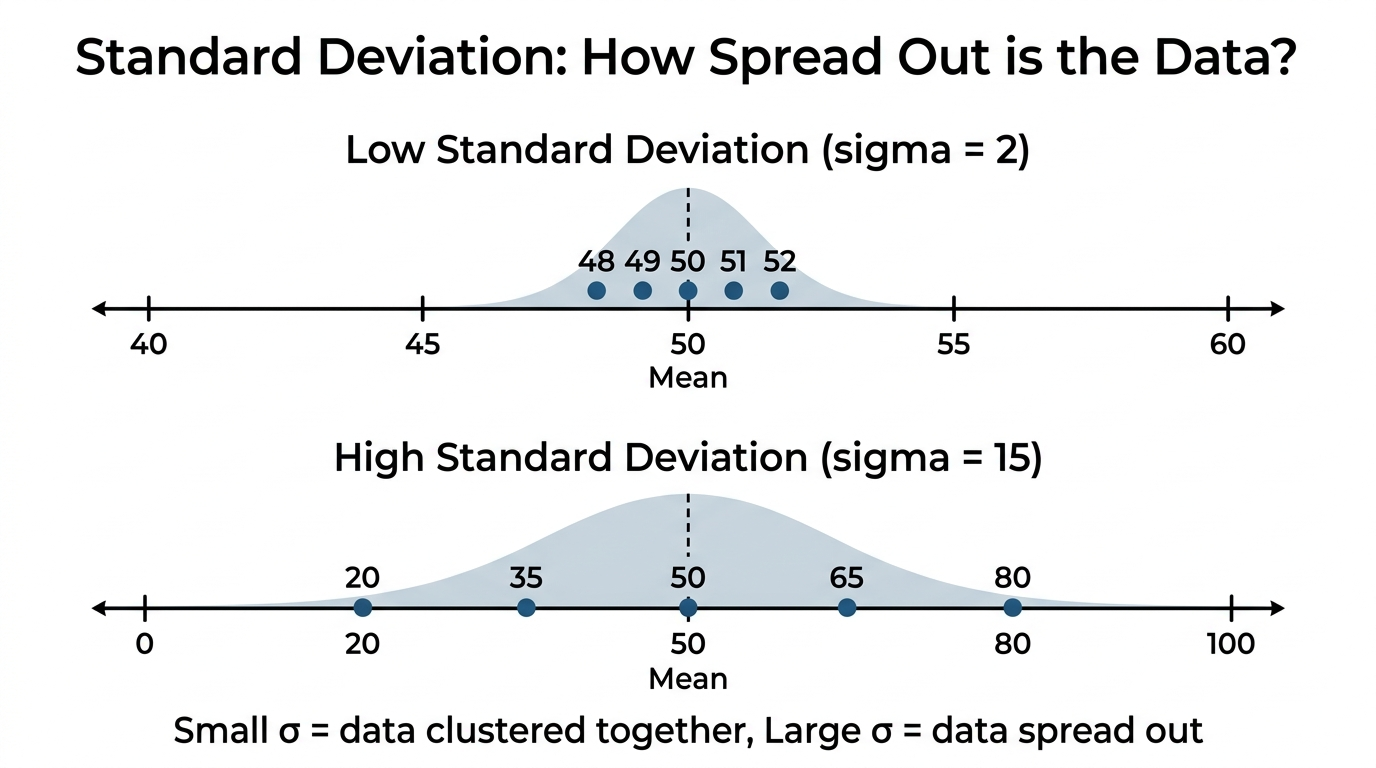![Standard Deviation — How Spread Out is the Data?](images/07_standard_deviation.jpg)

**Percentiles and IQR (Interquartile Range)**

**Percentiles** tell you what percentage of data falls below a certain value:
- **25th percentile (Q1):** 25% of data is below this value.
- **50th percentile (Q2):** Same as the median!
- **75th percentile (Q3):** 75% of data is below this value.
- **IQR = Q3 − Q1:** The range that contains the middle 50% of data.

IQR is useful for detecting **outliers** (unusual values).

In [ ]:

scores = np.array([72, 85, 90, 60, 72, 88, 95, 72, 50, 68])

# Percentiles:
q25 = np.percentile(scores, 25)
q50 = np.percentile(scores, 50)   # This is the median!
q75 = np.percentile(scores, 75)
iqr = q75 - q25

print(f"25th Percentile (Q1): {q25}")
print(f"50th Percentile (Q2 = Median): {q50}")
print(f"75th Percentile (Q3): {q75}")
print(f"IQR (Q3 - Q1): {iqr}")

25th Percentile (Q1): 69.0
50th Percentile (Q2 = Median): 72.0
75th Percentile (Q3): 87.25
IQR (Q3 - Q1): 18.25


**Correlation — Do two things change together?**

**Pearson Correlation ($r$)** measures how strongly two variables are linearly related:
- $r = +1$ → Perfect positive relationship (one goes up, the other goes up)
- $r = 0$ → No relationship
- $r = -1$ → Perfect negative relationship (one goes up, the other goes down)

*Example: Study hours and test scores usually have a positive correlation ($r > 0$).*
*Example: Screen time and test scores might have a negative correlation ($r < 0$).*

In [ ]:
# Example: Study hours vs Test scores
study_hours = np.array([1.5, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0])
test_scores = np.array([42,  50,  58,  68,  75,  82,  88,  95])

# Pearson Correlation:
correlation_matrix = np.corrcoef(study_hours, test_scores)
print(correlation_matrix)
r = correlation_matrix[0, 1]

print(f"Pearson Correlation (r): {r:.4f}")
if r > 0.7:
    print("Strong positive correlation — more study hours = higher scores!")
elif r > 0.3:
    print("Moderate positive correlation.")
else:
    print("Weak or no correlation.")

[[1.         0.99402982]
 [0.99402982 1.        ]]
Pearson Correlation (r): 0.9940
Strong positive correlation — more study hours = higher scores!


#### 📝 **Try It Yourself — Easy Statistics Questions**

**E9: Create a NumPy array of your daily screen time (in hours) for the last 7 days. Calculate and print the mean, median, min, and max using NumPy functions.**

In [ ]:
# E9: Code here


**E10: Given the list `[4, 8, 6, 5, 3, 8, 9, 8]`, find the mode (the most repeated value) using `Counter` from the `collections` module.**

In [ ]:
# E10: Code here


**E11: Given `data = [10, 20, 30, 40, 50]`, calculate the variance by hand using the formula: for each value, compute $(x_i - \text{mean})^2$, then average those squared differences. Verify with `np.var()`.**

In [ ]:
# E11: Code here


**E12: Use `np.percentile()` to find the 25th, 50th, and 75th percentiles of `[12, 15, 14, 10, 18, 20, 22, 16, 25, 13]`. Also compute the IQR.**

In [ ]:
# E12: Code here


### ▶ **Useful Mathematical Operations for AI & Data Science**

Let's learn some important math tools that are used in almost every AI/ML system:

**1. Distance Between Two Points**

Remember the distance formula from school? It works for any number of dimensions!

**Euclidean Distance** (straight-line distance):
$$d = \sqrt{(x_1 - x_2)^2 + (y_1 - y_2)^2 + \dots}$$

**Manhattan Distance** (grid/taxi distance — like walking on a city grid):
$$d = |x_1 - x_2| + |y_1 - y_2| + \dots$$

*Use case: Finding similar items, clustering data, k-nearest neighbors algorithm.*

**2. Feature Scaling (Making Data Fair)**

Imagine comparing "Age" (range: 18–60) with "Salary" (range: 20000–200000). The salary numbers are so much bigger that they would dominate any calculation.

**Solution: Scale all features to a similar range.**

**Min-Max Scaling** (scales data between 0 and 1):
$$x_{\text{scaled}} = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$

**Z-Score Standardization** (makes mean = 0, standard deviation = 1):
$$z = \frac{x - \text{mean}}{\text{std dev}}$$

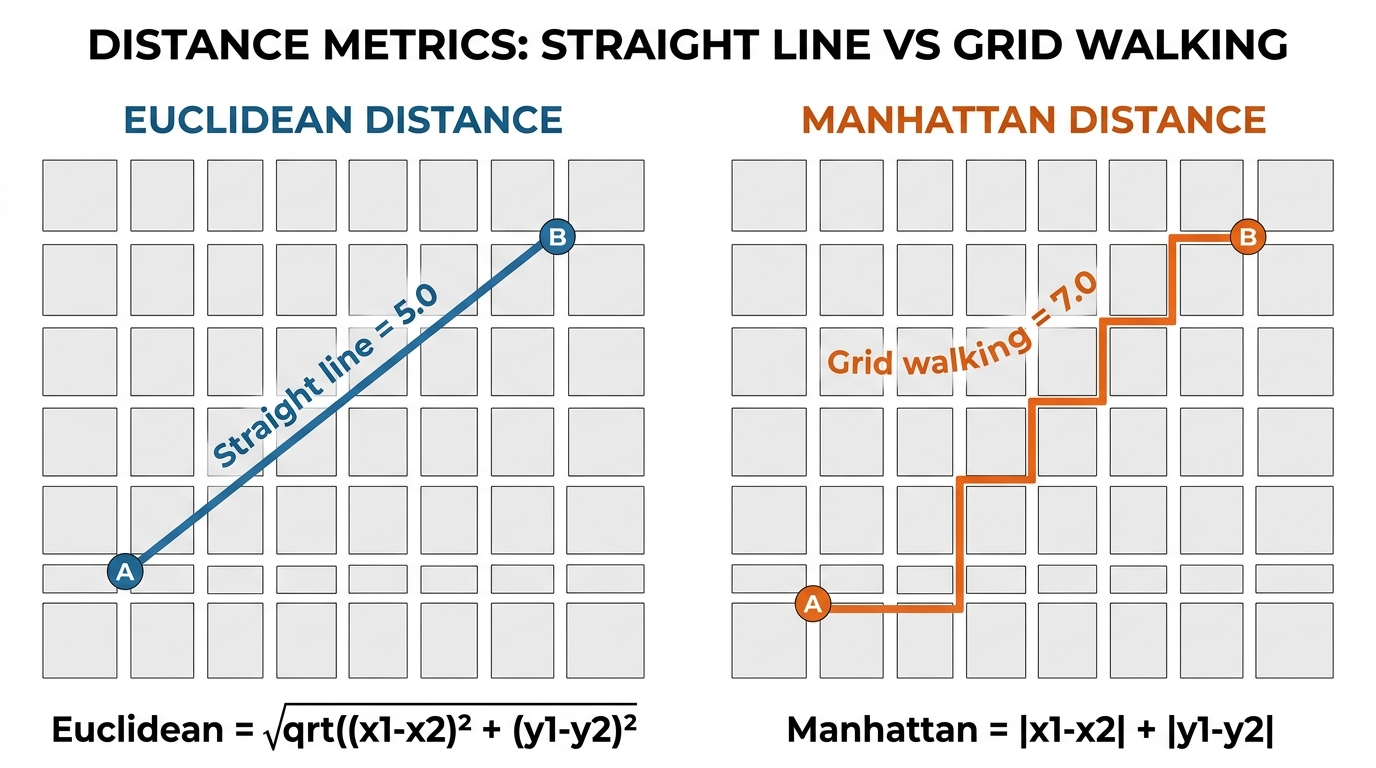![Distance Metrics — Euclidean vs Manhattan](images/08_distance_metrics.jpg)

In [ ]:
# Distance between two points:
point_A = np.array([1.0, 2.0, 3.0])
point_B = np.array([4.0, 6.0, 3.0])

# Euclidean Distance:
euclidean_dist = np.sqrt(np.sum((point_A - point_B) ** 2))
# Or simply: np.linalg.norm(point_A - point_B)
print(f"Euclidean Distance: {euclidean_dist:.4f}")

# Manhattan Distance:
manhattan_dist = np.sum(np.abs(point_A - point_B))
print(f"Manhattan Distance: {manhattan_dist:.4f}")

Euclidean Distance: 5.0000
Manhattan Distance: 7.0000


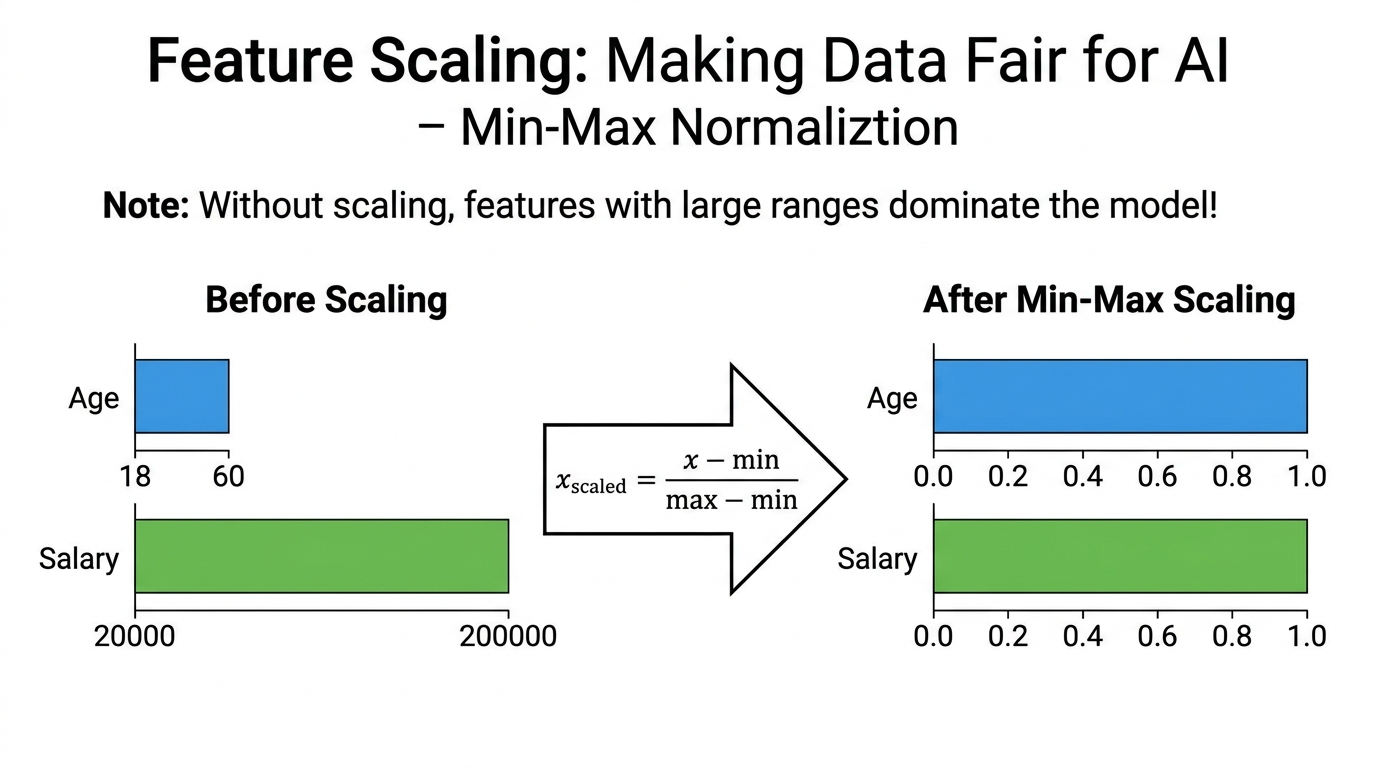![Feature Scaling — Making Data Fair for AI](images/09_feature_scaling.jpg)

In [ ]:
# Feature Scaling Example:
# Ages and Salaries of 5 employees:
ages = np.array([22.0, 35.0, 45.0, 28.0, 55.0])
salaries = np.array([25000.0, 50000.0, 80000.0, 35000.0, 120000.0])

# Min-Max Scaling (to range [0, 1]):
ages_scaled = (ages - np.min(ages)) / (np.max(ages) - np.min(ages))
salaries_scaled = (salaries - np.min(salaries)) / (np.max(salaries) - np.min(salaries))

print("Ages (original):", ages)
print("Ages (scaled 0-1):", np.round(ages_scaled, 4))
print("\nSalaries (original):", salaries)
print("Salaries (scaled 0-1):", np.round(salaries_scaled, 4))
print("\nNow both features are in the same range [0, 1]!")

Ages (original): [22. 35. 45. 28. 55.]
Ages (scaled 0-1): [0.     0.3939 0.697  0.1818 1.    ]

Salaries (original): [ 25000.  50000.  80000.  35000. 120000.]
Salaries (scaled 0-1): [0.     0.2632 0.5789 0.1053 1.    ]

Now both features are in the same range [0, 1]!


**3. Activation Functions (Neural Network Building Blocks)**

In neural networks, **activation functions** decide whether a neuron should "fire" (activate) or not.

**Sigmoid:** Squashes any number to a value between 0 and 1 (like a probability).
$$\sigma(z) = \frac{1}{1 + e^{-z}}$$
- Large positive $z$ → output close to 1
- Large negative $z$ → output close to 0
- $z = 0$ → output = 0.5

**ReLU (Rectified Linear Unit):** The simplest and most popular activation.
$$\text{ReLU}(z) = \max(0, z)$$
- If input is positive → output = input (pass through)
- If input is negative → output = 0 (block it)

**4. Loss Functions (How wrong is the AI model?)**

After making predictions, we need to measure how far off the model is from the correct answers.

**Mean Squared Error (MSE):** Average of squared errors. Penalizes large errors more.
$$\text{MSE} = \frac{1}{N} \sum (y_{\text{true}} - y_{\text{predicted}})^2$$

**Mean Absolute Error (MAE):** Average of absolute errors. Simpler to interpret.
$$\text{MAE} = \frac{1}{N} \sum |y_{\text{true}} - y_{\text{predicted}}|$$

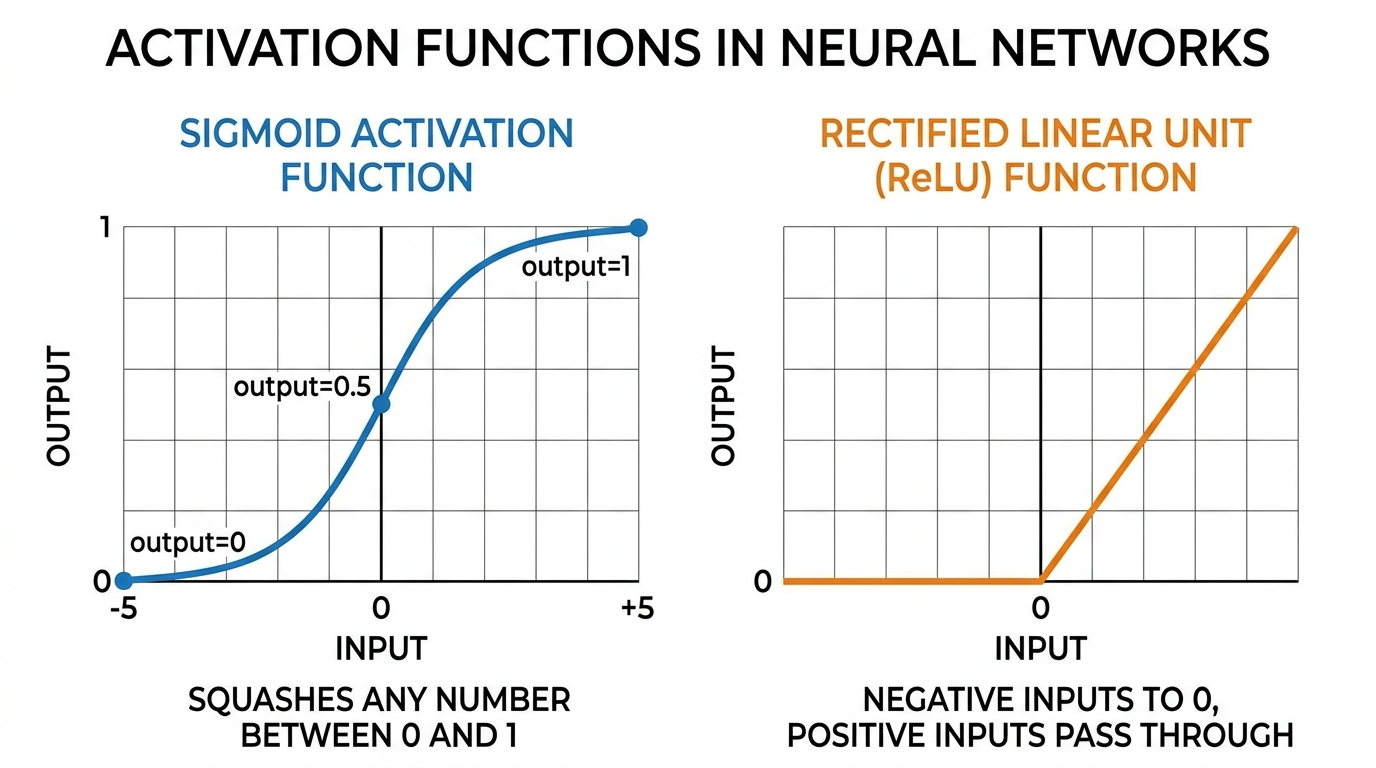![Activation Functions — Sigmoid & ReLU](images/10_sigmoid_relu.jpg)

In [ ]:
# Activation Functions:
inputs = np.array([-3.0, -1.0, 0.0, 1.0, 3.0])

# Sigmoid:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

# ReLU:
def relu(z):
    return np.maximum(0, z)

print("Inputs:  ", inputs)
print("Sigmoid: ", np.round(sigmoid(inputs), 4))
print("ReLU:    ", relu(inputs))

Inputs:   [-3. -1.  0.  1.  3.]
Sigmoid:  [0.0474 0.2689 0.5    0.7311 0.9526]
ReLU:     [0. 0. 0. 1. 3.]


In [ ]:
# Loss Functions:
# Suppose a model predicts house prices:
actual_prices  = np.array([200, 350, 150, 500, 420])    # True prices (in thousands)
predicted_prices = np.array([210, 330, 160, 480, 450])  # Model's predictions

errors = actual_prices - predicted_prices
print("Errors (residuals):", errors)

mse = np.mean(errors ** 2)
mae = np.mean(np.abs(errors))

print(f"\nMean Squared Error (MSE): {mse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mse):.2f}")

Errors (residuals): [-10  20 -10  20 -30]

Mean Squared Error (MSE): 380.00
Mean Absolute Error (MAE): 18.00
Root Mean Squared Error (RMSE): 19.49


#### 📝 **Try It Yourself — Easy Math Questions**

**E13: Find the Euclidean distance between the points $(1, 2)$ and $(4, 6)$ using the distance formula and verify with `np.linalg.norm()`.**

In [ ]:
# E13: Code here


**E14: Given the array `[100, 200, 300, 400, 500]`, apply Min-Max scaling to convert all values to the range $[0, 1]$. Print the scaled values.**

In [ ]:
# E14: Code here


**E15: Compute `sigmoid(0)`, `sigmoid(5)`, and `sigmoid(-5)` using the formula $\frac{1}{1 + e^{-z}}$. What pattern do you notice?**

In [ ]:
# E15: Code here


**E16: A model predicts `[10, 20, 30]` but the true values are `[12, 18, 33]`. Calculate the MAE (Mean Absolute Error) by hand and verify with NumPy.**

In [ ]:
# E16: Code here


### ▶ **Some Example Problems**

**Q1: Take two vectors of size 4: `u = [3, -2, 4, 1]` and `v = [2, 5, -1, 3]`. Write code to:**
1. **Compute vector addition $(u + v)$ using a `for` loop.**
2. **Compute the dot product $(u \cdot v)$ using a `for` loop (without `np.dot`).**
3. **Compute the Euclidean magnitude (length) of vector $u$ from scratch.**
4. **Verify all three results using NumPy functions.**

In [ ]:
# Q1: Code here
u = [3, -2, 4, 1]
v = [2, 5, -1, 3]

# Write your solution below:


**Q2: Write a function `normalize_vector(v)` that takes a vector (NumPy array) and returns its unit vector (magnitude = 1). Handle the edge case where the input is an all-zero vector (to avoid dividing by zero). Test on `[3.0, 4.0, 0.0, 12.0]`.**

In [ ]:
# Q2: Code here



**Q3: Create a $4 \times 4$ matrix with numbers 1 to 16 (Hint: `np.arange(1, 17).reshape(4, 4)`). Then:**
1. **Print the 3rd row (index 2).**
2. **Print the 2nd column (index 1).**
3. **Extract the center 2×2 submatrix (rows 1-2, columns 1-2).**
4. **Print the transpose of the matrix.**

In [ ]:
# Q3: Code here



**Q4: Neural Network Linear Transformation:**
**Given weight matrix $W$ of shape (2, 3), input vector $x$ of length 3, and bias vector $b$ of length 2:**
```python
W = [[0.5, -0.2, 0.1],
     [0.3,  0.8, -0.5]]
x = [2.0, 4.0, 1.0]
b = [0.1, -0.2]
```
**Compute and print the output $y = Wx + b$.**

In [ ]:
# Q4: Code here



**Q5: Given temperature readings `[23.5, 25.1, 24.8, 26.2, 22.9, 25.0, 24.3, 27.5, 23.8, 25.4]`:**
1. **Calculate Mean, Variance, and Standard Deviation from first principles (using `for` loops, without `np.mean`, `np.var`, `np.std`).**
2. **Verify your answers with NumPy functions.**

In [ ]:
# Q5: Code here
temps = [23.5, 25.1, 24.8, 26.2, 22.9, 25.0, 24.3, 27.5, 23.8, 25.4]



**Q6: Write a function `compute_median(data)` that sorts the list and returns the median. Handle both odd-length and even-length lists (without using `np.median`). Test on:**
- `[14, 3, 27, 8, 19]` → Expected: 14
- `[14, 3, 27, 8, 19, 45]` → Expected: 16.5

In [ ]:
# Q6: Code here



**Q7: Write a function `min_max_scale(data)` that takes a 2D NumPy matrix and scales each column independently to the range $[0, 1]$. Test on:**
```python
X = [[1000, 2, 20],
     [2500, 4, 35],
     [1800, 3, 28],
     [3200, 5, 45]]
```

In [ ]:
# Q7: Code here



**Q8: Write a function `standardize(data)` that applies Z-score standardization to each column of a 2D matrix (subtract column mean, divide by column standard deviation). Verify that after standardization, each column has mean ≈ 0 and std ≈ 1.**

In [ ]:
# Q8: Code here



**Q9: A model predicts test scores. Given true scores $y = [15.2, 21.0, 33.5, 40.2, 55.8]$ and predictions $\hat{y} = [14.0, 23.5, 31.0, 42.0, 52.1]$:**
1. **Compute individual errors $e_i = y_i - \hat{y}_i$.**
2. **Compute MAE (Mean Absolute Error).**
3. **Compute MSE (Mean Squared Error).**
4. **Compute RMSE (Root Mean Squared Error = $\sqrt{MSE}$).**

In [ ]:
# Q9: Code here
y_true = np.array([15.2, 21.0, 33.5, 40.2, 55.8])
y_pred = np.array([14.0, 23.5, 31.0, 42.0, 52.1])



**Q10: Implement `sigmoid(x)` and `relu(x)` functions. Apply both to 11 evenly spaced values from $-5$ to $+5$ (use `np.linspace(-5, 5, 11)`). Print the inputs, Sigmoid outputs, and ReLU outputs.**

In [ ]:
# Q10: Code here
x_vals = np.linspace(-5, 5, 11)



## ***More Questions — Higher Order Thinking Skills (HOTS)***

**Q11: Cosine Similarity for Document Matching**

Three documents are represented as word frequency vectors:
- $\text{Doc}_1 = [3, 1, 0, 2, 0, 1]$
- $\text{Doc}_2 = [2, 0, 1, 3, 1, 0]$
- $\text{Doc}_3 = [0, 1, 4, 0, 2, 3]$

**Task:**
1. Write a `cosine_similarity(v1, v2)` function.
2. Compute cosine similarity between all 3 pairs.
3. Print which pair of documents is **most similar**.

In [ ]:
# Q11: Code here
doc1 = np.array([3, 1, 0, 2, 0, 1])
doc2 = np.array([2, 0, 1, 3, 1, 0])
doc3 = np.array([0, 1, 4, 0, 2, 3])



**Q12: Numerically Stable Softmax**

The **Softmax** function converts a list of raw scores (logits) into probabilities that sum to 1:
$$p_i = \frac{e^{z_i}}{\sum_{j} e^{z_j}}$$

**Problem:** If $z_i$ is very large (e.g., 1000), then $e^{1000}$ causes overflow (infinity!).

**Fix:** Subtract $\max(z)$ from all values first — this doesn't change the result but prevents overflow:
$$p_i = \frac{e^{z_i - \max(z)}}{\sum_{j} e^{z_j - \max(z)}}$$

**Task:**
1. Implement `stable_softmax(logits)`.
2. Test on `[2.0, 1.0, 0.1]` — verify probabilities sum to 1.
3. Test on `[1000, 1001, 1002]` — verify it doesn't crash or give `nan`.

In [ ]:
# Q12: Code here



**Q13: Matrix Multiplication from Scratch**

Write `matrix_multiply(A, B)` using three nested `for` loops (without `@` or `np.matmul`):
1. Check that A's columns = B's rows. If not, print an error message.
2. Compute $C_{ij} = \sum_p A_{ip} \times B_{pj}$.
3. Compare your result with `A @ B`.

**Test on:**
$$A = \begin{bmatrix} 1 & 2 & 3 \\ 4 & 5 & 6 \end{bmatrix}, \quad B = \begin{bmatrix} 7 & 8 \\ 9 & 1 \\ 2 & 3 \end{bmatrix}$$

In [ ]:
# Q13: Code here
A = np.array([[1, 2, 3], [4, 5, 6]])
B = np.array([[7, 8], [9, 1], [2, 3]])



**Q14: 1-Nearest Neighbor Search**

Given a database of 5 items in 3D space and a new query point, find the closest item:
```python
database = [[1.2, 3.4, 5.1],
            [2.8, 1.1, 0.9],
            [5.0, 4.2, 3.3],
            [0.9, 3.1, 4.8],
            [3.1, 2.9, 1.5]]
query = [1.0, 3.0, 5.0]
```
**Task:** Compute the Euclidean distance from `query` to each database item. Print all distances and identify the nearest neighbor (smallest distance).

In [ ]:
# Q14: Code here
database = np.array([
    [1.2, 3.4, 5.1],
    [2.8, 1.1, 0.9],
    [5.0, 4.2, 3.3],
    [0.9, 3.1, 4.8],
    [3.1, 2.9, 1.5]
])
query = np.array([1.0, 3.0, 5.0])



**Q15: Correlation Analysis for Feature Selection**

Given data for 5 students: `[Study Hours, Sleep Hours, Test Score]`:
```python
data = [[8.0, 6.0, 88],
        [4.0, 8.5, 62],
        [6.5, 7.0, 78],
        [2.0, 9.0, 45],
        [9.0, 5.5, 95]]
```
**Task:**
1. Compute the correlation matrix using `np.corrcoef(data.T)`.
2. Print correlation of **Study Hours vs Test Score** and **Sleep Hours vs Test Score**.
3. In a comment, explain: Which feature is more strongly correlated with Test Score? What does a negative correlation mean here?

In [ ]:
# Q15: Code here
data = np.array([
    [8.0, 6.0, 88.0],
    [4.0, 8.5, 62.0],
    [6.5, 7.0, 78.0],
    [2.0, 9.0, 45.0],
    [9.0, 5.5, 95.0]
])



**Q16: Outlier Detection using Z-Score and IQR**

Housing prices (in thousands): `[150, 165, 172, 148, 155, 180, 162, 950, 158, 169, 175, 20, 160]`

Some values look suspicious (950 and 20). Let's detect them automatically:
1. **Z-Score method:** Compute Z-score for each value. Flag values with $|z| > 2$ as outliers.
2. **IQR method:** Compute Q1, Q3, and IQR. Flag values below $Q1 - 1.5 \times IQR$ or above $Q3 + 1.5 \times IQR$.
3. Print outliers detected by each method and compare.

In [ ]:
# Q16: Code here
prices = np.array([150, 165, 172, 148, 155, 180, 162, 950, 158, 169, 175, 20, 160])



**Q17: Finding the Best Slope for a Line (Linear Regression Grid Search)**

In linear regression, we predict $\hat{y} = w \cdot x + b$. We want the slope $w$ that gives the lowest error.

**Given:** $x = [1, 2, 3, 4, 5]$, $y = [2.2, 3.9, 6.1, 7.8, 10.2]$, bias $b = 0.1$.

**Task:**
1. Try different slopes: $w \in [1.0, 1.5, 2.0, 2.5, 3.0]$.
2. For each $w$, compute predictions $\hat{y} = wx + b$ and the MSE loss.
3. Print a table of $(w, \text{MSE})$ and find which $w$ gives the lowest error.

In [ ]:
# Q17: Code here
x_data = np.array([1.0, 2.0, 3.0, 4.0, 5.0])
y_data = np.array([2.2, 3.9, 6.1, 7.8, 10.2])
candidate_slopes = [1.0, 1.5, 2.0, 2.5, 3.0]
b = 0.1



**Q18: Gradient Descent — Teaching the AI to Learn!**

Gradient Descent is how AI models learn. The idea is simple:
1. Start with a random guess for a parameter $w$.
2. Compute how wrong you are (the loss).
3. Compute in which direction to adjust $w$ (the gradient).
4. Take a small step in that direction.
5. Repeat!

**Loss function:** $f(w) = (w - 4)^2 + 10$ → minimum is at $w = 4$ where loss = 10.

**Gradient (slope):** $\frac{df}{dw} = 2(w - 4)$

**Update rule:** $w_{\text{new}} = w_{\text{old}} - \alpha \times \text{gradient}$ (where $\alpha = 0.1$ is the learning rate)

**Task:**
1. Start at $w_0 = 0.0$, learning rate $\alpha = 0.1$.
2. Run 25 iterations. In each step: compute loss, compute gradient, update $w$.
3. Print $w$ and loss every 5 steps. Observe how $w$ converges to 4.0.

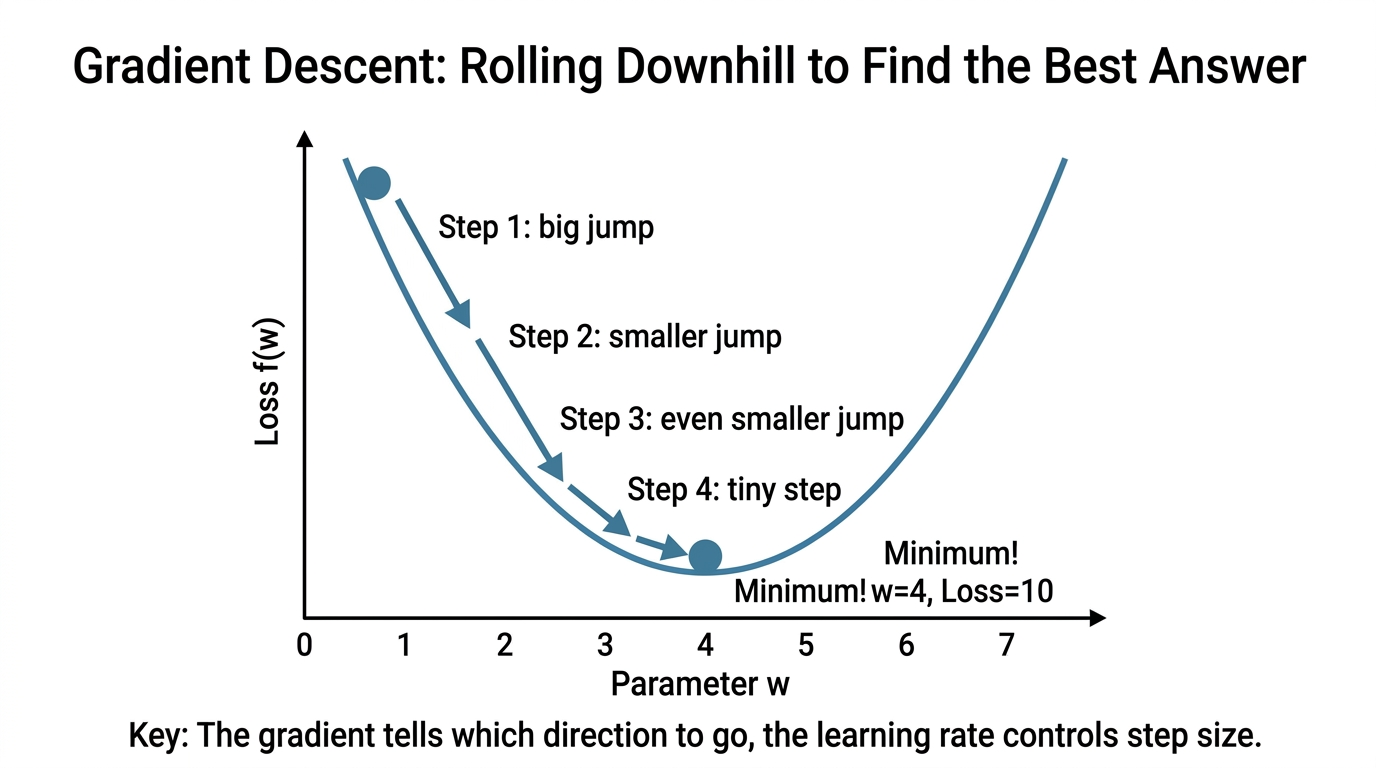![Gradient Descent — Rolling Downhill to Find the Best Answer](images/11_gradient_descent.jpg)

In [ ]:
# Q18: Code here
w = 0.0
learning_rate = 0.1
num_iterations = 25

